# Fase 3 — Validación y Comparativa de modelos

**Thesis:** Comparativa de algoritmos para la predicción de la demanda eléctrica  
**Author:** Antonio Navarro  

This notebook:
1. Loads all saved predictions and metrics (Naive t-168, SARIMAX, LSTM, TTM zero-shot, TTM few-shot)
2. Computes a unified metrics table (MAPE, RMSE, MAE, training time, inference time)
3. Produces publication-quality comparison plots (Weekly actual vs predicted, Bar charts, Scatter plots, Computational efficiency)
4. Exports final comparison tables to CSV and Google Drive

In [2]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Colab: clone or update the repo, then cd into it ──────────────────────────
REPO_NAME = "pred_demanda"
REPO_URL  = "https://github.com/antonionc/pred_demanda.git"

if os.path.exists("data_utils.py"):
    !git pull
elif os.path.isdir(REPO_NAME):
    %cd {REPO_NAME}
    !git pull
elif os.path.exists(f"/content/{REPO_NAME}"):
    %cd /content/{REPO_NAME}
    !git pull
elif os.path.exists("/content"):
    !git clone {REPO_URL}
    %cd {REPO_NAME}
# ──────────────────────────────────────────────────────────────────────────────

sys.path.insert(0, os.path.abspath('.'))
import data_utils as du

# Mount Google Drive in Colab and create persistent links for data/, cache/, saved_models/
du.setup_colab_drive()

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})
sns.set_theme(style='whitegrid')
print('Environment ready.')

Cloning into 'pred_demanda'...
remote: Enumerating objects: 152, done.
remote: Counting objects: 100% (152/152), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 152 (delta 87), reused 84 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (152/152), 4.85 MiB | 23.64 MiB/s, done.
Resolving deltas: 100% (87/87), done.
/content/pred_demanda
[Colab] Requesting scoped access to Google Drive ('drive.file')...


  [DriveSync] Downloading data/fig_ttm_fewshot_week.png...
  [DriveSync] Downloading data/fig_ttm_zeroshot_week.png...
  [DriveSync] Downloading data/fig_pearson_correlation.png...
  [DriveSync] Downloading data/fig_naive_week_zoom.png...
  [DriveSync] Downloading data/fig_computational_efficiency.png...
  [DriveSync] Downloading data/metrics_ttm_fewshot.json...
  [DriveSync] Downloading data/fig_naive_full_year.png...
  [DriveSync] Downloading data/fig_lstm_test.png...
  [DriveSync] Downloading data/fig_stl_decomposition.png...
  [DriveSync] Downloading data/fig_ttm_comparison_week.png...
  [DriveSync] Downloading data/features_test.csv...
  [DriveSync] Downloading data/fig_data_split.png...
  [DriveSync] Downloading data/predictions_naive.csv...
  [DriveSync] Downloading data/features_val.csv...
  [DriveSync] Downloading data/predictions_sarimax.csv...
  [DriveSync] Downloading data/fig_acf_pacf.png...
  [DriveSync] Downloading data/fig_sarimax_week.png...
  [DriveSync] Downloading d

## 1 · Load saved predictions & metrics

In [3]:
def load_preds(path):
    df = pd.read_csv(path)
    # Standardize to tz-naive UTC datetime to prevent tz-naive vs tz-aware comparison errors
    df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_localize(None)
    df = df.sort_values('datetime').reset_index(drop=True)
    return df

pred_files = {
    'Naive (t-168)' : 'data/predictions_naive.csv',
    'SARIMAX'       : 'data/predictions_sarimax.csv',
    'LSTM'          : 'data/predictions_lstm.csv',
    'TTM zero-shot' : 'data/predictions_ttm_zeroshot.csv',
    'TTM few-shot'  : 'data/predictions_ttm_fewshot.csv',
}

preds = {}
for name, path in pred_files.items():
    if os.path.exists(path):
        preds[name] = load_preds(path)
        print(f'{name:<18}: {len(preds[name]):,} rows  ({preds[name]["datetime"].min().date()} → {preds[name]["datetime"].max().date()})')
    else:
        print(f'{name:<18}: NOT FOUND — run the corresponding notebook first')

Naive (t-168)     : 9,754 rows  (2024-06-20 → 2025-07-31)
SARIMAX           : 9,744 rows  (2024-06-20 → 2025-07-31)
LSTM              : 9,576 rows  (2024-06-27 → 2025-07-31)
TTM zero-shot     : 9,744 rows  (2024-06-20 → 2025-07-31)
TTM few-shot      : 9,744 rows  (2024-06-20 → 2025-07-31)


In [4]:
# Load metrics JSON files
metric_files = {
    'Naive (t-168)' : 'data/metrics_naive.json',
    'SARIMAX'       : 'data/metrics_sarimax.json',
    'LSTM'          : 'data/metrics_lstm.json',
    'TTM zero-shot' : 'data/metrics_ttm_zeroshot.json',
    'TTM few-shot'  : 'data/metrics_ttm_fewshot.json',
}

all_metrics = {}
for name, path in metric_files.items():
    if os.path.exists(path):
        with open(path) as f:
            all_metrics[name] = json.load(f)
        print(f'{name:<18}: MAPE={all_metrics[name].get("mape", 0):.3f}% | RMSE={all_metrics[name].get("rmse", 0):.1f} MW | Train={all_metrics[name].get("train_s", 0):.1f}s | Infer={all_metrics[name].get("inference_s", 0):.3f}s')
    else:
        print(f'{name:<18}: metrics file NOT FOUND')

# Fallback: if predictions exist but metrics file was not saved, compute directly
for name, df in preds.items():
    if name not in all_metrics:
        m = du.compute_metrics(df['y_true'].values, df['y_pred'].values, label=name)
        m['train_s'] = 0.0
        m['inference_s'] = 0.0
        all_metrics[name] = m

Naive (t-168)     : MAPE=6.560% | RMSE=2243.4 MW | Train=0.0s | Infer=0.055s
SARIMAX           : MAPE=8.309% | RMSE=3220.3 MW | Train=1041.5s | Infer=1086.179s
LSTM              : MAPE=5.747% | RMSE=1694.0 MW | Train=419.2s | Infer=0.542s
TTM zero-shot     : MAPE=6.109% | RMSE=1828.7 MW | Train=0.0s | Infer=0.995s
TTM few-shot      : MAPE=5.479% | RMSE=1661.4 MW | Train=24.6s | Infer=0.101s


## 2 · Unified Metrics Comparison Table

              MAPE (%) RMSE (MW) MAE (MW) Train time (s) Inference (s)
Model                                                                 
Naive (t-168)    6.560    2243.4   1445.9            0.0         0.055
SARIMAX          8.309    3220.3   1955.1         1041.5      1086.179
LSTM             5.747    1694.0   1204.1          419.2         0.542
TTM zero-shot    6.109    1828.7   1336.1            0.0         0.995
TTM few-shot     5.479    1661.4   1183.8           24.6         0.101
Figure saved → data/fig_comparison_table.png


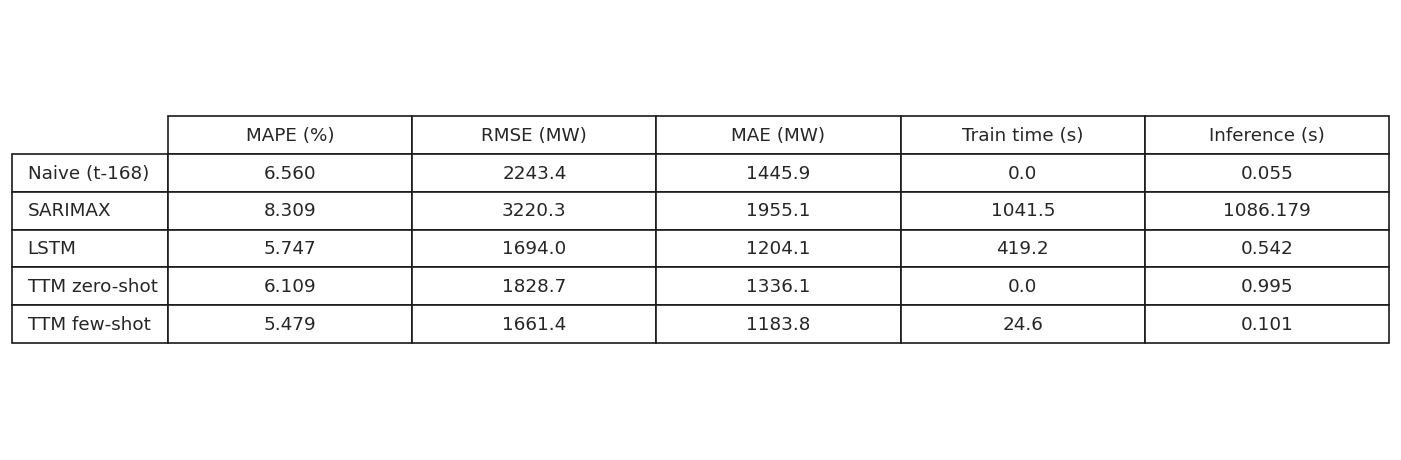


Saved → data/comparison_table.csv


In [5]:
summary_df = du.plot_comparison_table(
    all_metrics,
    figsize = (12, max(3, len(all_metrics) * 0.6 + 1)),
    save_path = 'data/fig_comparison_table.png',
)
summary_df.to_csv('data/comparison_table.csv')
print('\nSaved → data/comparison_table.csv')

## 3 · Visual Comparison

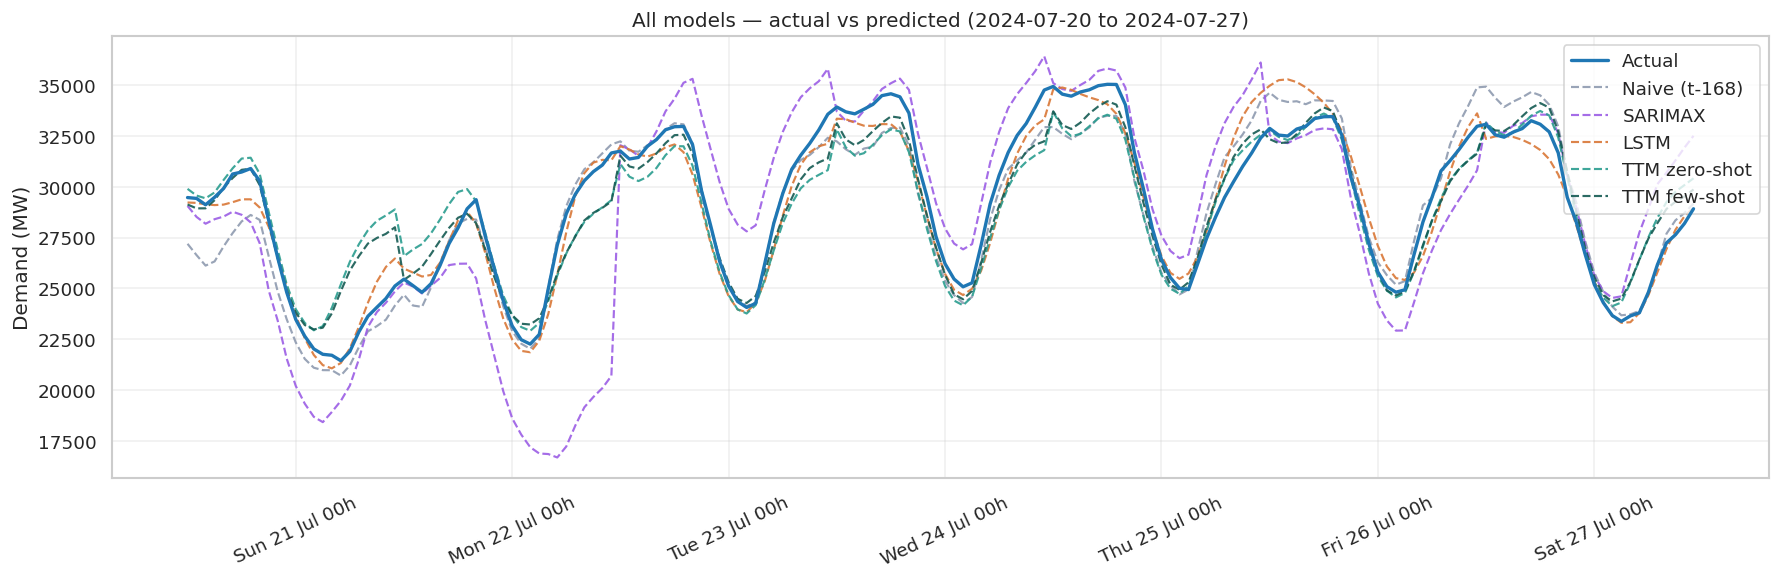

In [6]:
# Choose a representative week for plotting from the first available model
if preds:
    first_model = list(preds.keys())[0]
    df_ref = preds[first_model]
    dates_ref = df_ref['datetime']

    PLOT_DAYS  = 7
    PLOT_START = dates_ref.min() + pd.Timedelta(days=30)
    PLOT_END   = PLOT_START + pd.Timedelta(days=PLOT_DAYS)

    model_colors = {
      'Naive (t-168)': '#8E9AAF',
      'SARIMAX'      : '#9B5DE5',
      'LSTM'         : '#D97736',
      'TTM zero-shot': '#2A9D8F',
      'TTM few-shot' : '#145A52',
    }

    fig, ax = plt.subplots(figsize=(15, 5))

    # Plot actual demand from reference model
    mask_ref = (dates_ref >= PLOT_START) & (dates_ref < PLOT_END)
    ax.plot(dates_ref[mask_ref], df_ref['y_true'][mask_ref], label='Actual', color='#1f77b4', linewidth=2.0, zorder=10)

    # Overlay model predictions
    for name, df in preds.items():
        d = df['datetime']
        mask = (d >= PLOT_START) & (d < PLOT_END)
        if mask.sum() > 0:
            ax.plot(d[mask], df['y_pred'][mask], label=name,
                    color=model_colors.get(name, 'gray'), linewidth=1.3, linestyle='--', alpha=0.9)

    ax.set_title(f'All models — actual vs predicted ({PLOT_START.date()} to {PLOT_END.date()})')
    ax.set_ylabel('Demand (MW)')
    ax.legend(loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b %Hh'))
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig('data/fig_all_models_week.png', dpi=150, bbox_inches='tight')
    plt.show()

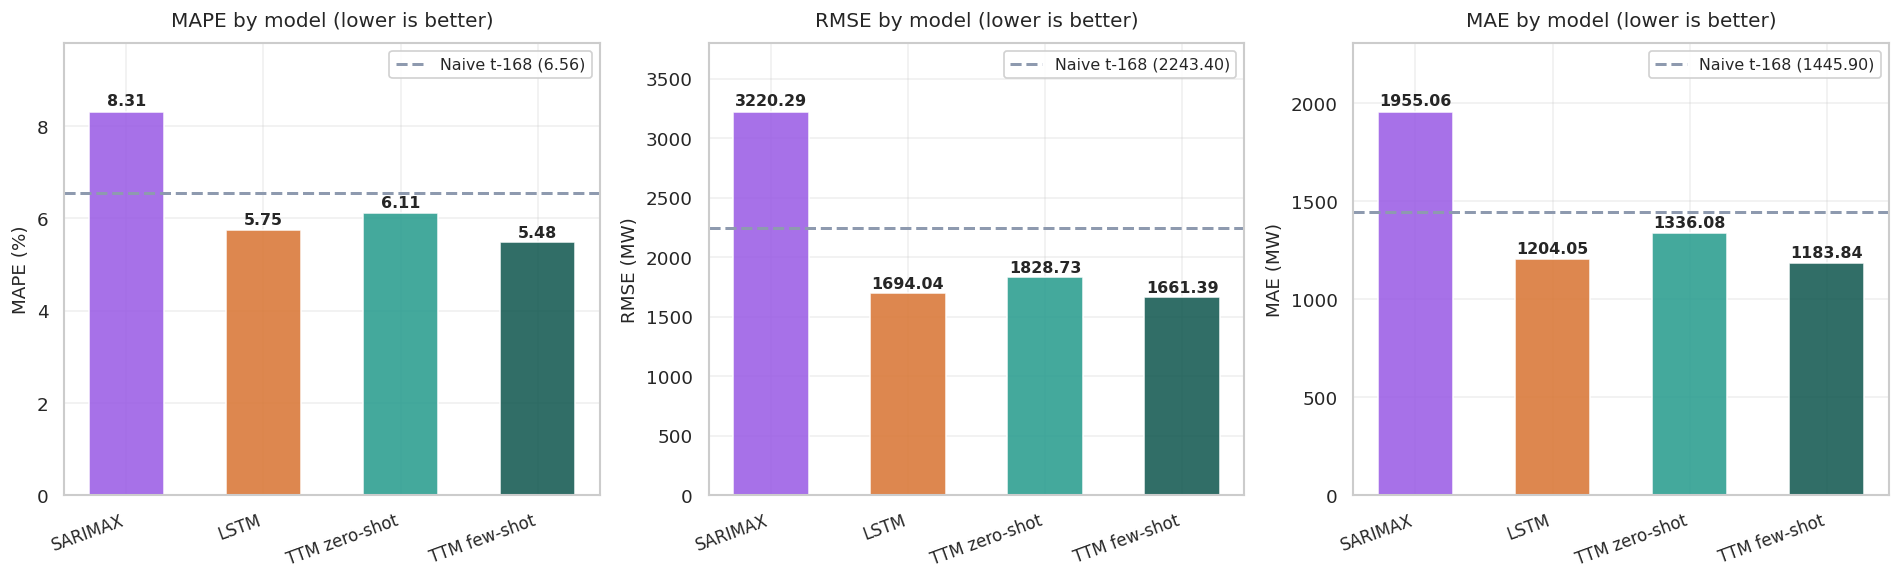

In [12]:
# Bar charts: MAPE, RMSE, MAE across models with Naive baseline as horizontal line
if all_metrics:
    naive_key = 'Naive (t-168)'
    has_naive = naive_key in all_metrics
    naive_color = model_colors.get(naive_key, '#8E9AAF')

    # Exclude Naive from the bars so it acts purely as the benchmark threshold
    bar_names = [n for n in all_metrics.keys() if n != naive_key]
    mapes = [all_metrics[n]['mape'] for n in bar_names]
    rmses = [all_metrics[n]['rmse'] for n in bar_names]
    maes  = [all_metrics[n]['mae']  for n in bar_names]

    naive_vals = {
        'mape': all_metrics[naive_key]['mape'] if has_naive else None,
        'rmse': all_metrics[naive_key]['rmse'] if has_naive else None,
        'mae' : all_metrics[naive_key]['mae']  if has_naive else None,
    }

    x = np.arange(len(bar_names))
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    metrics_config = [
        (axes[0], mapes, naive_vals['mape'], 'MAPE (%)',  'MAPE by model (lower is better)'),
        (axes[1], rmses, naive_vals['rmse'], 'RMSE (MW)', 'RMSE by model (lower is better)'),
        (axes[2], maes,  naive_vals['mae'],  'MAE (MW)',  'MAE by model (lower is better)'),
    ]

    for ax, vals, naive_val, ylabel, title in metrics_config:
        # 1. Bars for evaluated models
        bars = ax.bar(x, vals, color=[model_colors.get(n, '#7f7f7f') for n in bar_names], alpha=0.88, width=0.55)
        ax.set_xticks(x)
        ax.set_xticklabels(bar_names, rotation=20, ha='right', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12, pad=10)

        # Value label on top of each bar
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

        # 2. Horizontal dashed baseline for Naive (t-168)
        if naive_val is not None:
            ax.axhline(
                y=naive_val,
                color=naive_color,
                linestyle='--',
                linewidth=1.8,
                label=f'Naive t-168 ({naive_val:.2f})'
            )
            ax.legend(loc='upper right', frameon=True, framealpha=0.9, fontsize=9.5)
            # Add headroom so labels and legend do not collide
            ax.set_ylim(0, max(max(vals), naive_val) * 1.18)
        else:
            ax.set_ylim(0, max(vals) * 1.15)

    plt.tight_layout()
    plt.savefig('data/fig_metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


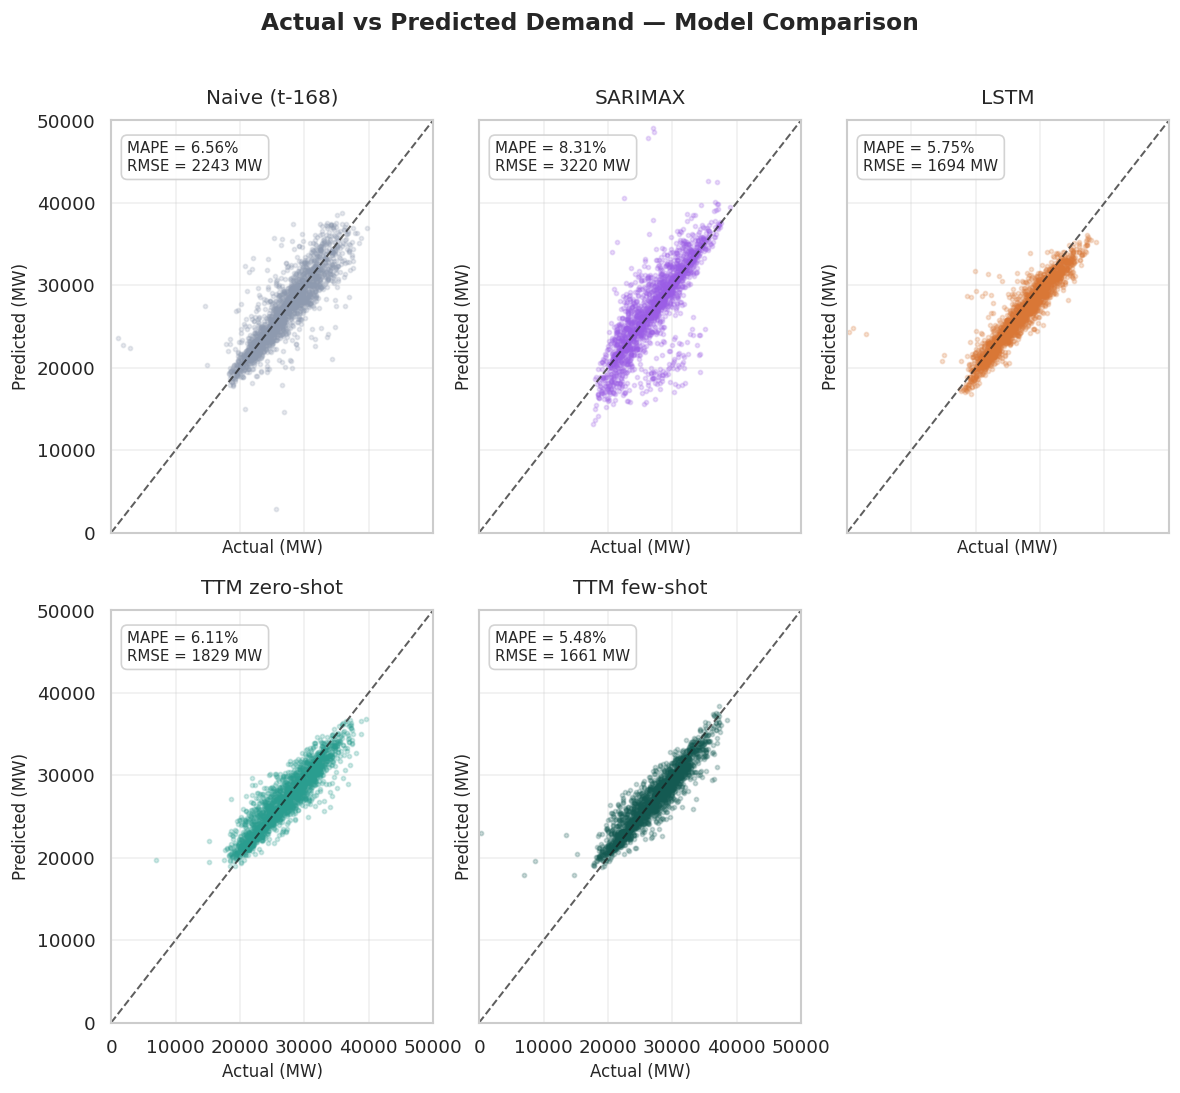

In [17]:
# Scatter plots in 2 columns
if preds:
    N_SCATTER = 2000
    n_models  = len(preds)

    n_cols = 3
    n_rows = int(np.ceil(n_models / n_cols))  # 5 models -> 3 rows

    global_lims = [0, 50000]

    # figsize = (width, height)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4.5 * n_rows), sharex=True, sharey=True)
    axes = axes.flatten()  # Flatten 2D array to 1D for the loop

    for i, (name, df) in enumerate(preds.items()):
        ax = axes[i]
        idx_sample = np.random.choice(len(df), size=min(N_SCATTER, len(df)), replace=False)
        yt = df['y_true'].values[idx_sample]
        yp = df['y_pred'].values[idx_sample]

        ax.scatter(yt, yp, alpha=0.22, s=6, color=model_colors.get(name, '#7f7f7f'))
        ax.plot(global_lims, global_lims, 'k--', linewidth=1.2, alpha=0.7)

        ax.set_xlim(global_lims)
        ax.set_ylim(global_lims)
        ax.set_title(name, fontsize=12, pad=10)
        ax.set_xlabel('Actual (MW)', fontsize=10)
        ax.set_ylabel('Predicted (MW)', fontsize=10)

        m = all_metrics.get(name, {})
        txt = f"MAPE = {m.get('mape', 0):.2f}%\nRMSE = {m.get('rmse', 0):.0f} MW"
        ax.text(0.05, 0.95, txt,
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))

    # Hide the 6th empty subplot
    for j in range(n_models, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Actual vs Predicted Demand — Model Comparison', y=1.01, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/fig_scatter_all_models.png', dpi=150, bbox_inches='tight')
    plt.show()


## 4 · Computational Efficiency Comparison

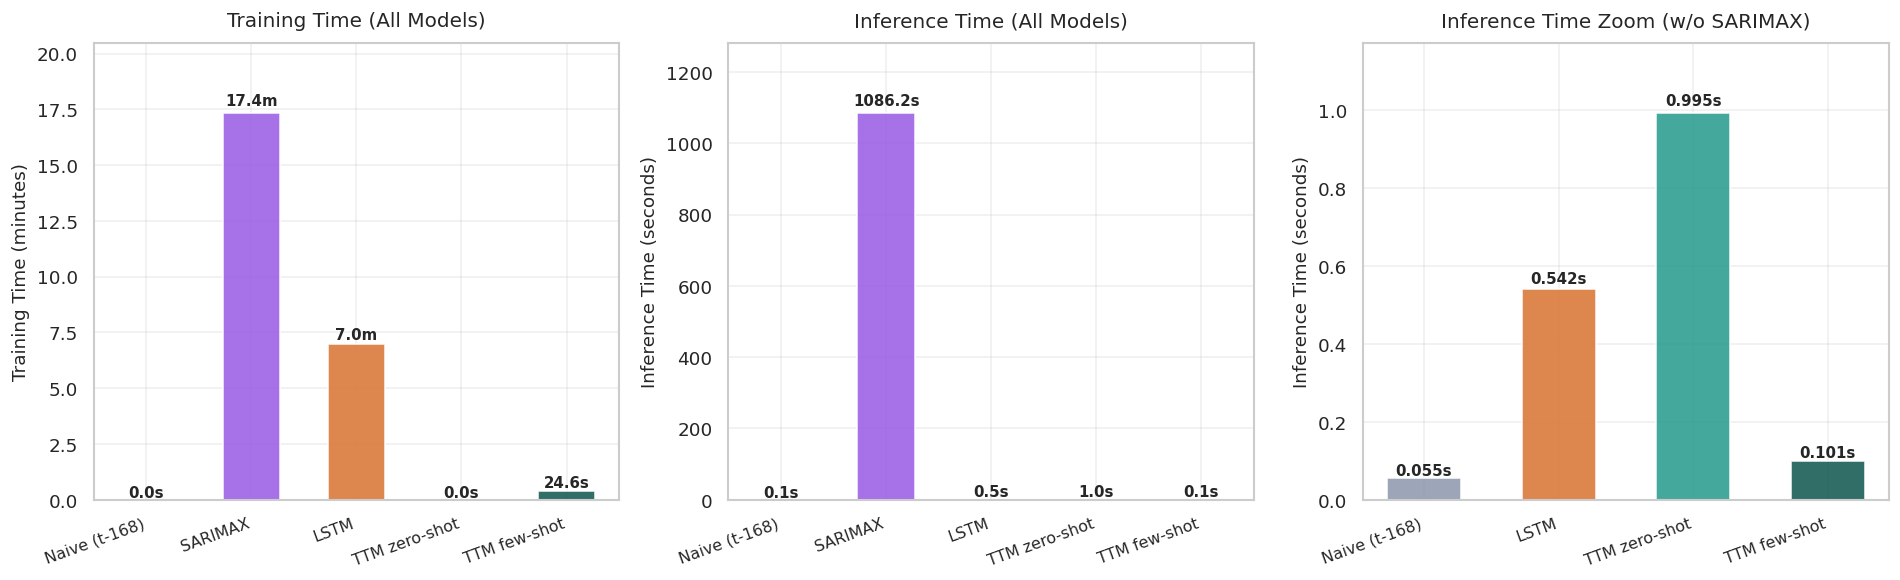

In [15]:
# Computational efficiency: Training & Inference time (with SARIMAX-excluded zoom)
if all_metrics:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1. Training time (minutes) - All models
    train_models = list(all_metrics.keys())
    train_vals_min = [all_metrics[n].get('train_s', 0) / 60 for n in train_models]
    x0 = np.arange(len(train_models))

    bars0 = axes[0].bar(x0, train_vals_min, color=[model_colors.get(n, '#7f7f7f') for n in train_models], alpha=0.88, width=0.55)
    axes[0].set_xticks(x0)
    axes[0].set_xticklabels(train_models, rotation=20, ha='right', fontsize=9.5)
    axes[0].set_ylabel('Training Time (minutes)', fontsize=11)
    axes[0].set_title('Training Time (All Models)', fontsize=12, pad=10)
    axes[0].set_ylim(0, max(train_vals_min) * 1.18 if max(train_vals_min) > 0 else 1)

    for bar, v, s in zip(bars0, train_vals_min, [all_metrics[n].get('train_s', 0) for n in train_models]):
        txt = f'{v:.1f}m' if v >= 1 else f'{s:.1f}s'
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                     txt, ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 2. Inference time (seconds) - All models (including SARIMAX)
    infer_models_all = list(all_metrics.keys())
    infer_vals_all = [all_metrics[n].get('inference_s', 0) for n in infer_models_all]
    x1 = np.arange(len(infer_models_all))

    bars1 = axes[1].bar(x1, infer_vals_all, color=[model_colors.get(n, '#7f7f7f') for n in infer_models_all], alpha=0.88, width=0.55)
    axes[1].set_xticks(x1)
    axes[1].set_xticklabels(infer_models_all, rotation=20, ha='right', fontsize=9.5)
    axes[1].set_ylabel('Inference Time (seconds)', fontsize=11)
    axes[1].set_title('Inference Time (All Models)', fontsize=12, pad=10)
    axes[1].set_ylim(0, max(infer_vals_all) * 1.18 if max(infer_vals_all) > 0 else 1)

    for bar, v in zip(bars1, infer_vals_all):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                     f'{v:.1f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 3. Inference time zoom (seconds) - Excluding SARIMAX
    infer_models_fast = [n for n in all_metrics.keys() if 'SARIMAX' not in n]
    infer_vals_fast = [all_metrics[n].get('inference_s', 0) for n in infer_models_fast]
    x2 = np.arange(len(infer_models_fast))

    bars2 = axes[2].bar(x2, infer_vals_fast, color=[model_colors.get(n, '#7f7f7f') for n in infer_models_fast], alpha=0.88, width=0.55)
    axes[2].set_xticks(x2)
    axes[2].set_xticklabels(infer_models_fast, rotation=20, ha='right', fontsize=9.5)
    axes[2].set_ylabel('Inference Time (seconds)', fontsize=11)
    axes[2].set_title('Inference Time Zoom (w/o SARIMAX)', fontsize=12, pad=10)
    axes[2].set_ylim(0, max(infer_vals_fast) * 1.18 if len(infer_vals_fast) > 0 and max(infer_vals_fast) > 0 else 1)

    for bar, v in zip(bars2, infer_vals_fast):
        axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                     f'{v:.3f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig('data/fig_computational_efficiency.png', dpi=150, bbox_inches='tight')
    plt.show()


## 5 · Final Results Table & Export

In [18]:
rows = []
for name, m in all_metrics.items():
    rows.append({
        'Model'          : name,
        'MAPE (%)'       : round(m['mape'],  3),
        'RMSE (MW)'      : round(m['rmse'],  1),
        'MAE (MW)'       : round(m['mae'],   1),
        'Train time (s)' : round(m.get('train_s', 0), 1),
        'Inference (s)'  : round(m.get('inference_s', 0), 3),
    })

final_table = pd.DataFrame(rows).set_index('Model')
print(final_table.to_string())
final_table.to_csv('data/final_results_table.csv')
print('\nSaved → data/final_results_table.csv')

# Sync outputs to Google Drive (if in Colab)
du.sync_to_drive()


               MAPE (%)  RMSE (MW)  MAE (MW)  Train time (s)  Inference (s)
Model                                                                      
Naive (t-168)     6.560     2243.4    1445.9             0.0          0.055
SARIMAX           8.309     3220.3    1955.1          1041.5       1086.179
LSTM              5.747     1694.0    1204.1           419.2          0.542
TTM zero-shot     6.109     1828.7    1336.1             0.0          0.995
TTM few-shot      5.479     1661.4    1183.8            24.6          0.101

Saved → data/final_results_table.csv
  [DriveSync] Uploading data/fig_sarimax_test.png to Drive...
  [DriveSync] Uploading data/fig_lstm_residuals.png to Drive...
  [DriveSync] Uploading data/fig_naive_scatter_residuals.png to Drive...
  [DriveSync] Uploading data/metrics_lstm.json to Drive...
  [DriveSync] Uploading data/predictions_lstm.csv to Drive...
  [DriveSync] Uploading data/comparison_table.csv to Drive...
  [DriveSync] Uploading data/fig_boxcox.png to D

True

## Summary

| Model | MAPE (%) | RMSE (MW) | MAE (MW) | Train (min) | Inference (s) |
|-------|:--------:|:---------:|:--------:|:-----------:|:-------------:|
| **Naive (t-168)** | … | … | … | **0.0** | **< 0.05** |
| **SARIMAX**        | … | … | … | …       | …          |
| **LSTM**           | … | … | … | …       | …          |
| **TTM zero-shot**  | … | … | … | **0.0** | …          |
| **TTM few-shot**   | … | … | … | …       | …          |

**Best model:** …  
**Conclusions:** …

In [11]:
#Terminate runtime
from google.colab import runtime
#runtime.unassign()